# Task 5 — Time-Series Forecasting

## Objective

The objective of this task is to build an end-to-end time-series forecasting pipeline for daily demand data.

The analysis includes:

- Time-series exploration
- Trend, seasonality, and residual decomposition
- Augmented Dickey-Fuller (ADF) stationarity testing
- Differencing when required
- ARIMA/SARIMA forecasting
- Model evaluation using MAPE and RMSE
- 30-day future demand forecasting

## Dataset

The dataset contains daily demand observations along with marketing-event and holiday information.

The main forecasting variable is:

`demand`

In [1]:
# Import libraries and load the time-series dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

data_path = Path("../data/daily-demand-series.csv")

df = pd.read_csv(data_path)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Rows: 30
Columns: 4

Column names:
['date', 'demand', 'marketing_event', 'holiday']

Missing values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

First 5 rows:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [2]:
# Explore the time-series data

print("Date range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())

print("\nDemand statistics:")
display(df["demand"].describe())

print("\nData types:")
print(df.dtypes)

print("\nTime-series frequency:")
print(df["date"].diff().value_counts())

print("\nFirst 10 observations:")
display(df.head(10))

Date range:
Start: 2026-06-01 00:00:00
End: 2026-06-30 00:00:00

Demand statistics:


count     30.000000
mean     142.100000
std       13.839848
min      118.000000
25%      132.500000
50%      142.000000
75%      150.250000
max      174.000000
Name: demand, dtype: float64


Data types:
date               datetime64[us]
demand                      int64
marketing_event             int64
holiday                     int64
dtype: object

Time-series frequency:
date
1 days    29
Name: count, dtype: int64

First 10 observations:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0
5,2026-06-06,151,1,0
6,2026-06-07,143,0,1
7,2026-06-08,126,0,0
8,2026-06-09,129,0,0
9,2026-06-10,132,0,0


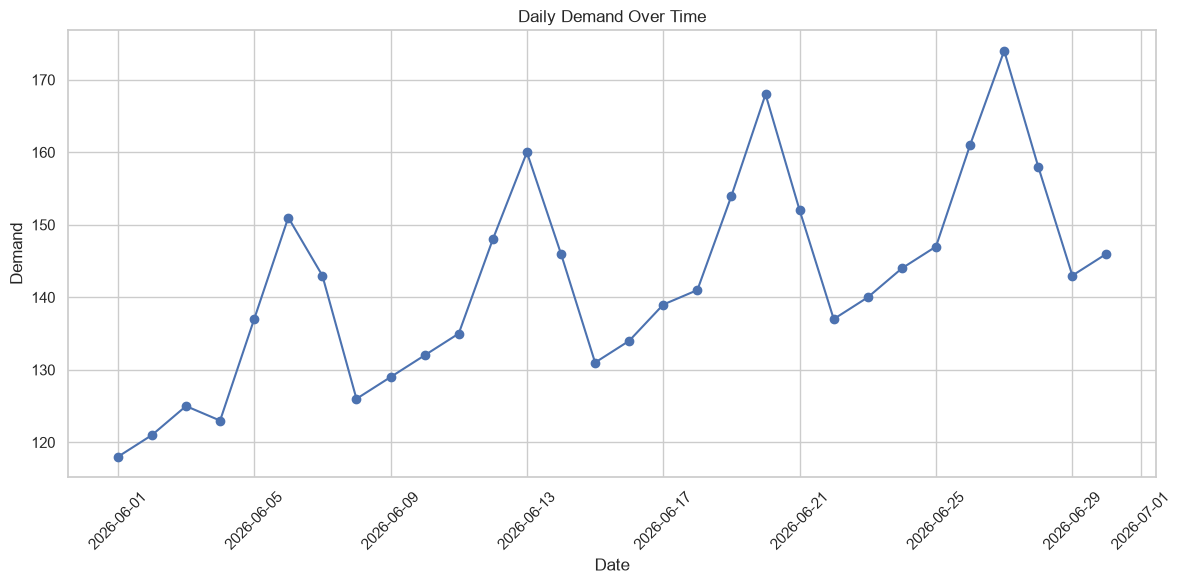

In [3]:
# Plot daily demand over time

plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["demand"],
    marker="o"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()